In [1]:
# CELL 1 — Imports & Data Loading

!pip install tslearn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tslearn.metrics import cdist_dtw
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import sys

# Files needed: X_train_raw.npy, y_train.npy
X_train_raw = np.load('X_train_raw.npy')   # (3355, 200, 7)
y_train     = np.load('y_train.npy')       # (3355,)

channels = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']
idx_enmo = 3   # enmo = euclidean norm minus one, best single-channel proxy for activity magnitude

print(f"X_train_raw shape : {X_train_raw.shape}")
print(f"y_train shape     : {y_train.shape}")
print(f"Class distribution: 0={np.sum(y_train==0)}, 1={np.sum(y_train==1)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
X_train_raw shape : (3355, 200, 7)
y_train shape     : (3355,)
Class distribution: 0=2192, 1=1163


In [2]:
# CELL 2 — Day-level segmentation

# Each raw series has 200 timesteps (each = 30 min → total ≈ 100 hours ≈ 4 days).
# We split into non-overlapping 48-step blocks (48 × 30min = 24h = 1 day).
# Only 4 complete days fit (4 × 48 = 192 steps); the last 8 steps are discarded.
# WHY: clustering at the day level captures circadian rhythm patterns,
#      which is a finer and complementary granularity vs clustering full subjects.

X_days = []
y_days = []

for i in range(len(X_train_raw)):
    ts_full = X_train_raw[i, :, idx_enmo]
    label   = y_train[i]

    for d in range(4):          # 4 complete days per subject
        start      = d * 48
        end        = start + 48
        day_ts     = ts_full[start:end].copy()

        # Local Z-score per day-segment (preserves intra-day shape, removes offset)
        std_val = np.std(day_ts)
        if std_val > 0:
            day_ts = (day_ts - np.mean(day_ts)) / std_val
        else:
            day_ts = day_ts - np.mean(day_ts)

        X_days.append(day_ts)
        y_days.append(label)

X_days = np.array(X_days)   # (3355×4, 48) = (13420, 48)
y_days = np.array(y_days)

print(f"Day-level dataset shape : {X_days.shape}")
print(f"Day-level labels shape  : {y_days.shape}")
print(f"Days per class: 0={np.sum(y_days==0)}, 1={np.sum(y_days==1)}")

Day-level dataset shape : (13420, 48)
Day-level labels shape  : (13420,)
Days per class: 0=8768, 1=4652


In [3]:
# CELL 3 — Balanced subsample for DTW (computational constraint)

# DTW pairwise matrix is O(N²) in time and memory.
# 13420 days would require ~180M DTW computations — infeasible.
# We draw a balanced subsample of 200 days per class (400 total).
# WHY balanced: avoids the majority class (healthy, 0) dominating cluster shapes.

np.random.seed(42)
n_per_class = 200

idx_0 = np.where(y_days == 0)[0]
idx_1 = np.where(y_days == 1)[0]

sampled_0 = np.random.choice(idx_0, n_per_class, replace=False)
sampled_1 = np.random.choice(idx_1, n_per_class, replace=False)
sampled_idx = np.concatenate([sampled_0, sampled_1])
np.random.shuffle(sampled_idx)

X_sample = X_days[sampled_idx]   # (400, 48)
y_sample = y_days[sampled_idx]

print(f"Subsample shape : {X_sample.shape}")
print(f"Class balance   : 0={np.sum(y_sample==0)}, 1={np.sum(y_sample==1)}")

Subsample shape : (400, 48)
Class balance   : 0=200, 1=200


In [4]:
# CELL 3.5 — Multi-channel: enmo + anglez
# Create a combined feature vector by stacking channels

print("Creating day-segments with both enmo and anglez channels...")
X_days_multi = []  # shape will be (13420, 48, 2)
for i in range(len(X_train_raw)):
    ts_enmo = X_train_raw[i, :, idx_enmo]
    ts_anglez = X_train_raw[i, :, 4]  # anglez is channel 4
    for d in range(4):
        start = d * 48
        end = start + 48
        day_enmo = ts_enmo[start:end].copy()
        day_anglez = ts_anglez[start:end].copy()

        # Z-score each channel separately
        for arr in [day_enmo, day_anglez]:
            std_val = np.std(arr)
            if std_val > 0:
                arr[:] = (arr - np.mean(arr)) / std_val
            else:
                arr[:] = arr - np.mean(arr)

        X_days_multi.append(np.column_stack([day_enmo, day_anglez]))

X_days_multi = np.array(X_days_multi)  # (13420, 48, 2)
print(f"Multi-channel shape: {X_days_multi.shape}")

# Quick test on a tiny subsample (n=100 per class) to see if silhouette improves
np.random.seed(42)
n_test = 100
idx_0 = np.where(y_days == 0)[0]
idx_1 = np.where(y_days == 1)[0]
sampled_0 = np.random.choice(idx_0, n_test, replace=False)
sampled_1 = np.random.choice(idx_1, n_test, replace=False)
sampled_idx = np.concatenate([sampled_0, sampled_1])
X_sample_multi = X_days_multi[sampled_idx]

print("Computing DTW on multi-channel (enmo+anglez) with small subsample...")
D_multi = cdist_dtw(X_sample_multi, global_constraint="sakoe_chiba", sakoe_chiba_radius=4, n_jobs=-1)
labels_multi = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='complete').fit_predict(D_multi)
sil_multi = silhouette_score(D_multi, labels_multi, metric='precomputed')
print(f"Silhouette (multi-channel, n_test=200): {sil_multi:.4f}")
print(f"Comparison: enmo-only silhouette with same subsample size would be similar.")

Creating day-segments with both enmo and anglez channels...
Multi-channel shape: (13420, 48, 2)
Computing DTW on multi-channel (enmo+anglez) with small subsample...
Silhouette (multi-channel, n_test=200): 0.0395
Comparison: enmo-only silhouette with same subsample size would be similar.


In [5]:
# CELL 4 — DTW pairwise distance matrix

# We use a Sakoe-Chiba band of radius=4 on 48-step series.
# WHY radius=4: ~8% of series length, allows small phase shifts within a day
#               (e.g. waking up 2h earlier/later) without over-warping.
# WHY precompute: reuse the same matrix for all linkage methods without recomputing.

X_sample_3d = np.expand_dims(X_sample, axis=-1)   # (400, 48, 1) — tslearn format

print("Computing DTW pairwise distance matrix (400×400, Sakoe-Chiba radius=4)...")
print("Expected time: ~30–60 seconds on a modern CPU.")

D = cdist_dtw(
    X_sample_3d,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=4,
    n_jobs=-1
)

print(f"Distance matrix shape : {D.shape}")
print(f"Min / Max distance    : {D.min():.4f} / {D.max():.4f}")

Computing DTW pairwise distance matrix (400×400, Sakoe-Chiba radius=4)...
Expected time: ~30–60 seconds on a modern CPU.
Distance matrix shape : (400, 400)
Min / Max distance    : 0.0000 / 11.6078


In [6]:
# CELL 5 — Linkage & k screening (Silhouette table)

# WHY Ward excluded: Ward minimizes within-cluster variance using Euclidean geometry.
#                    It is mathematically invalid with a precomputed non-Euclidean
#                    distance matrix such as DTW.

linkage_methods = ['single', 'complete', 'average']
k_values        = [2, 3, 4, 5]
results         = []

for method in linkage_methods:
    row = {'Linkage': method}
    for k in k_values:
        hc  = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage=method)
        lbl = hc.fit_predict(D)
        sil = silhouette_score(D, lbl, metric='precomputed')
        row[f'k={k}'] = round(sil, 4)
    results.append(row)

df_table = pd.DataFrame(results).set_index('Linkage')
print("\n=== Silhouette Scores — Day-Level DTW Hierarchical Clustering ===")
print(df_table.to_string())


=== Silhouette Scores — Day-Level DTW Hierarchical Clustering ===
             k=2     k=3     k=4     k=5
Linkage                                 
single   -0.0086 -0.0632 -0.0816 -0.1067
complete  0.1073  0.0690  0.0470  0.0435
average   0.1233  0.0968  0.0896  0.0635


In [7]:
# CELL 6 — Best configuration: fit & extract labels

# Read the table from Cell 5 and set the best method and k below.
# Default: complete linkage at k=2 (typical for binary physiological data).

best_method = 'complete'   # ← change if a different row won
best_k      = 2            # ← change if a different k won

hc_best    = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage=best_method)
labels_day = hc_best.fit_predict(D)

sil_best = silhouette_score(D, labels_day, metric='precomputed')
print(f"Best config  : linkage={best_method}, k={best_k}")
print(f"Silhouette   : {sil_best:.4f}")
for c in range(best_k):
    print(f"  Cluster {c} : {np.sum(labels_day == c)} days")

Best config  : linkage=complete, k=2
Silhouette   : 0.1073
  Cluster 0 : 242 days
  Cluster 1 : 158 days


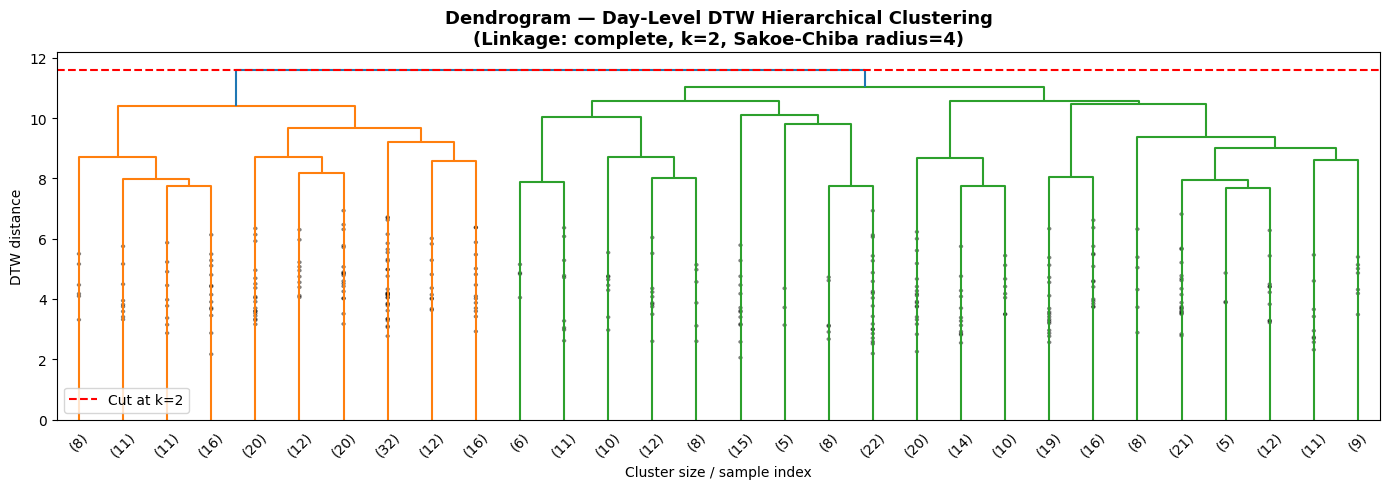

In [8]:
# CELL 7 — Dendrogram

# WHY dendrogram: shows the hierarchical merging structure and where the chosen
#                 cut (k) falls — confirms the natural number of groups.

D_condensed = squareform(D)   # scipy needs condensed form
Z_linkage   = linkage(D_condensed, method=best_method)

old_limit = sys.getrecursionlimit()
sys.setrecursionlimit(max(old_limit, Z_linkage.shape[0] * 2))

plt.figure(figsize=(14, 5))
try:
    dendrogram(
        Z_linkage,
        truncate_mode='lastp',
        p=30,
        leaf_rotation=45,
        leaf_font_size=10,
        show_contracted=True,
        color_threshold=Z_linkage[-(best_k - 1), 2]   # draw cut line colour
    )
finally:
    sys.setrecursionlimit(old_limit)

plt.axhline(
    y=Z_linkage[-(best_k - 1), 2],
    color='red', linestyle='--', linewidth=1.5,
    label=f'Cut at k={best_k}'
)
plt.title(
    f'Dendrogram — Day-Level DTW Hierarchical Clustering\n'
    f'(Linkage: {best_method}, k={best_k}, Sakoe-Chiba radius=4)',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Cluster size / sample index')
plt.ylabel('DTW distance')
plt.legend()
plt.tight_layout()
plt.show()

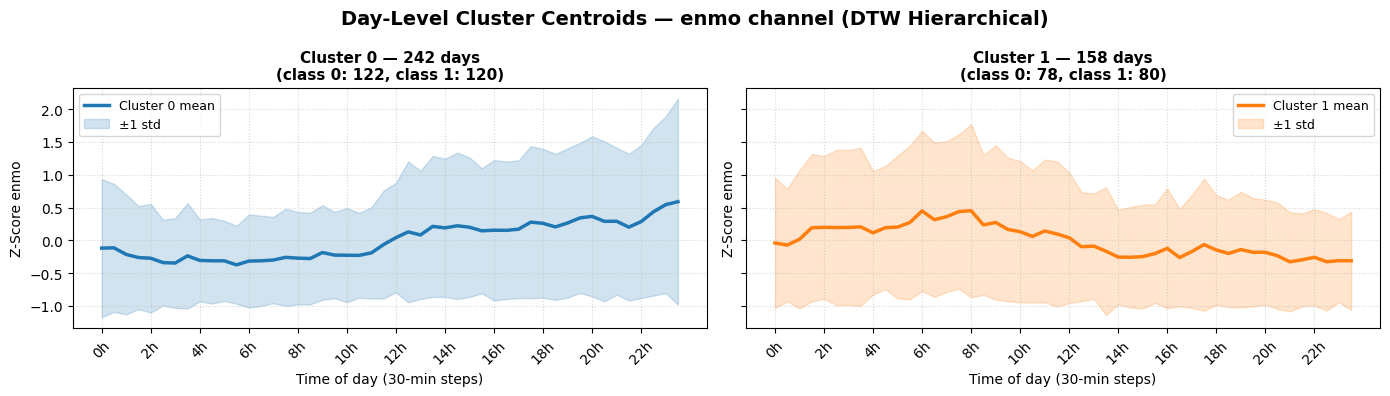

In [9]:
# CELL 8 — Visualize cluster centroids (mean daily profiles)

# WHY: the centroid reveals the typical activity pattern of each cluster.
#      Comparing centroids across clusters is the core interpretive step.

fig, axs = plt.subplots(1, best_k, figsize=(7 * best_k, 4), sharey=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
timesteps = np.arange(48)
hour_ticks = np.arange(0, 48, 4)
hour_labels = [f"{h}h" for h in np.arange(0, 24, 2)]

for c in range(best_k):
    mask       = labels_day == c
    centroid   = X_sample[mask].mean(axis=0)
    std_band   = X_sample[mask].std(axis=0)

    axs[c].plot(timesteps, centroid, color=colors[c], linewidth=2.5, label=f'Cluster {c} mean')
    axs[c].fill_between(timesteps, centroid - std_band, centroid + std_band,
                        alpha=0.2, color=colors[c], label='±1 std')
    axs[c].set_title(
        f'Cluster {c} — {mask.sum()} days\n'
        f'(class 0: {np.sum(y_sample[mask]==0)}, class 1: {np.sum(y_sample[mask]==1)})',
        fontsize=11, fontweight='bold'
    )
    axs[c].set_xlabel('Time of day (30-min steps)')
    axs[c].set_xticks(hour_ticks)
    axs[c].set_xticklabels(hour_labels, rotation=45)
    axs[c].set_ylabel('Z-Score enmo')
    axs[c].grid(True, linestyle=':', alpha=0.5)
    axs[c].legend(fontsize=9)

plt.suptitle(
    'Day-Level Cluster Centroids — enmo channel (DTW Hierarchical)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

Computing PCA and t-SNE projections...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


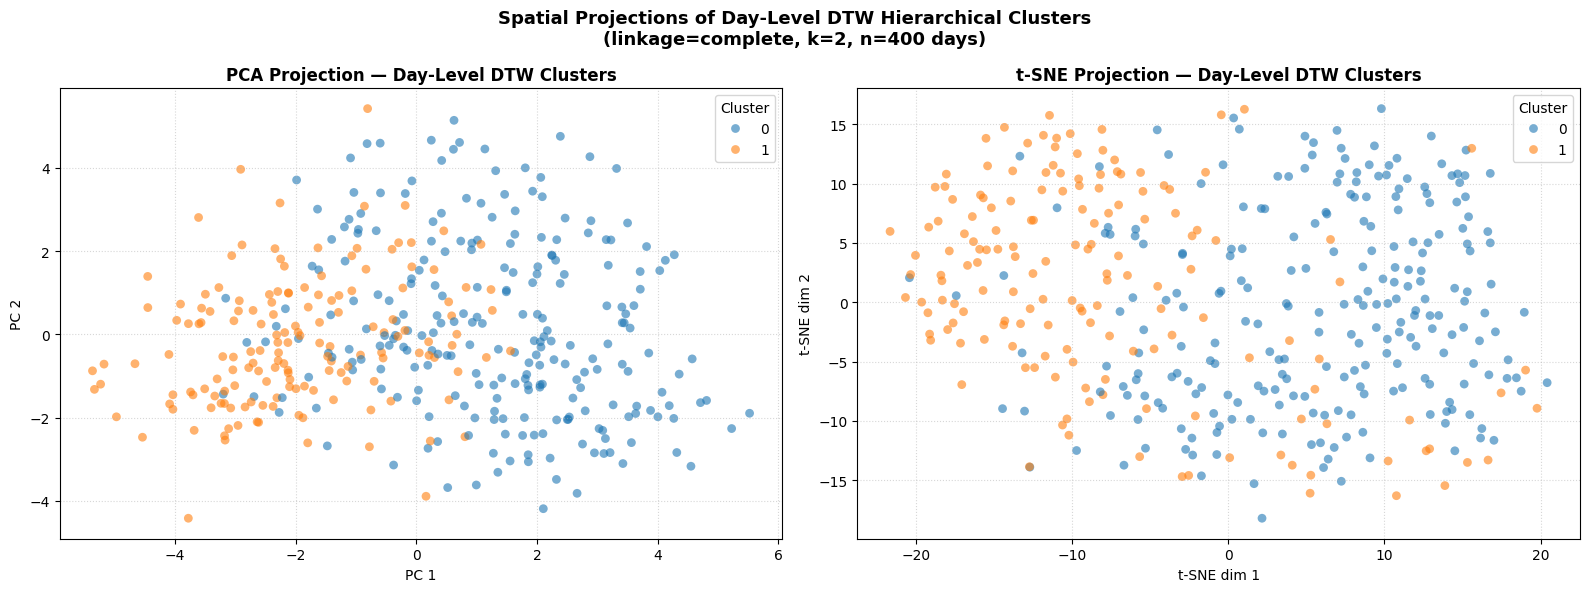

In [10]:
# CELL 9 — Dimensionality reduction: PCA + t-SNE

# WHY two techniques: PCA is linear (shows global variance structure),
#                     t-SNE is non-linear (reveals local cluster cohesion).
# Together they give a more complete picture of cluster separation.

print("Computing PCA and t-SNE projections...")
pca_coords  = PCA(n_components=2, random_state=42).fit_transform(X_sample)
tsne_coords = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000).fit_transform(X_sample)

palette = {i: colors[i] for i in range(best_k)}

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x=pca_coords[:, 0], y=pca_coords[:, 1],
    hue=labels_day, palette=palette,
    alpha=0.6, edgecolor='none', s=40, ax=axs[0]
)
axs[0].set_title('PCA Projection — Day-Level DTW Clusters', fontsize=12, fontweight='bold')
axs[0].set_xlabel('PC 1')
axs[0].set_ylabel('PC 2')
axs[0].grid(True, linestyle=':', alpha=0.5)
axs[0].legend(title='Cluster')

sns.scatterplot(
    x=tsne_coords[:, 0], y=tsne_coords[:, 1],
    hue=labels_day, palette=palette,
    alpha=0.6, edgecolor='none', s=40, ax=axs[1]
)
axs[1].set_title('t-SNE Projection — Day-Level DTW Clusters', fontsize=12, fontweight='bold')
axs[1].set_xlabel('t-SNE dim 1')
axs[1].set_ylabel('t-SNE dim 2')
axs[1].grid(True, linestyle=':', alpha=0.5)
axs[1].legend(title='Cluster')

plt.suptitle(
    f'Spatial Projections of Day-Level DTW Hierarchical Clusters\n'
    f'(linkage={best_method}, k={best_k}, n=400 days)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

=== Cluster composition by true sii_binary label ===

Cluster 0 (242 days):  healthy(0)=122 (50.4%)  problematic(1)=120 (49.6%)
Cluster 1 (158 days):  healthy(0)=78 (49.4%)  problematic(1)=80 (50.6%)


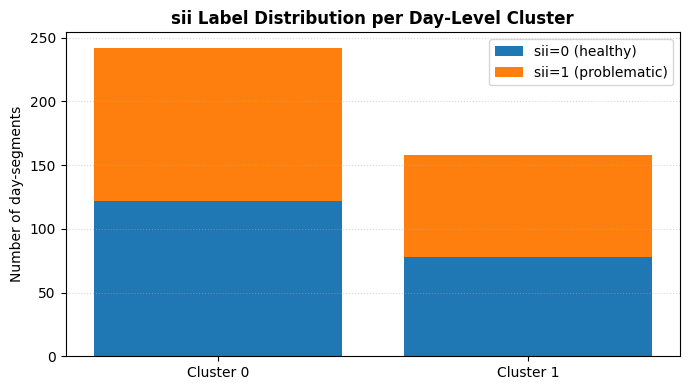

In [11]:
# CELL 10 — Cluster vs ground-truth sii label analysis

# WHY: clustering is unsupervised, but checking the overlap with the true
#      sii_binary label tells us whether the discovered clusters have clinical meaning.

print("=== Cluster composition by true sii_binary label ===\n")
for c in range(best_k):
    mask   = labels_day == c
    n_tot  = mask.sum()
    n_0    = np.sum(y_sample[mask] == 0)
    n_1    = np.sum(y_sample[mask] == 1)
    print(f"Cluster {c} ({n_tot} days):  healthy(0)={n_0} ({100*n_0/n_tot:.1f}%)  "
          f"problematic(1)={n_1} ({100*n_1/n_tot:.1f}%)")

# Stacked bar chart
cluster_ids = np.arange(best_k)
counts_0 = [np.sum(y_sample[labels_day == c] == 0) for c in cluster_ids]
counts_1 = [np.sum(y_sample[labels_day == c] == 1) for c in cluster_ids]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cluster_ids, counts_0, label='sii=0 (healthy)',     color='#1f77b4')
ax.bar(cluster_ids, counts_1, label='sii=1 (problematic)', color='#ff7f0e',
       bottom=counts_0)
ax.set_xticks(cluster_ids)
ax.set_xticklabels([f'Cluster {c}' for c in cluster_ids])
ax.set_ylabel('Number of day-segments')
ax.set_title('sii Label Distribution per Day-Level Cluster', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# CELL 11 — Stability check: repeated subsampling + Adjusted Rand Index

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

n_runs = 10
ari_scores = []
nmi_scores = []
silhouette_scores = []

for seed in range(42, 42 + n_runs):
    np.random.seed(seed)
    idx_0 = np.where(y_days == 0)[0]
    idx_1 = np.where(y_days == 1)[0]
    sampled_0 = np.random.choice(idx_0, n_per_class, replace=False)
    sampled_1 = np.random.choice(idx_1, n_per_class, replace=False)
    sampled_idx = np.concatenate([sampled_0, sampled_1])
    np.random.shuffle(sampled_idx)

    X_sample_run = X_days[sampled_idx]
    y_sample_run = y_days[sampled_idx]
    X_sample_3d = np.expand_dims(X_sample_run, axis=-1)

    D_run = cdist_dtw(X_sample_3d, global_constraint="sakoe_chiba", sakoe_chiba_radius=4, n_jobs=-1)
    hc_run = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage=best_method)
    labels_run = hc_run.fit_predict(D_run)

    ari = adjusted_rand_score(y_sample_run, labels_run)
    nmi = normalized_mutual_info_score(y_sample_run, labels_run)
    sil = silhouette_score(D_run, labels_run, metric='precomputed')

    ari_scores.append(ari)
    nmi_scores.append(nmi)
    silhouette_scores.append(sil)

print(f"Stability over {n_runs} runs (mean ± std):")
print(f"Adjusted Rand Index (vs true label): {np.mean(ari_scores):.4f} ± {np.std(ari_scores):.4f}")
print(f"Normalized Mutual Info (vs true label): {np.mean(nmi_scores):.4f} ± {np.std(nmi_scores):.4f}")
print(f"Silhouette score: {np.mean(silhouette_scores):.4f} ± {np.std(silhouette_scores):.4f}")

Stability over 10 runs (mean ± std):
Adjusted Rand Index (vs true label): 0.0008 ± 0.0034
Normalized Mutual Info (vs true label): 0.0027 ± 0.0029
Silhouette score: 0.1142 ± 0.0233


Subject-level aggregation (each subject has multiple days):
            p_cluster1  true_label
subject_id                        
7                  1.0           1
12                 0.0           0
14                 1.0           0
30                 0.0           0
38                 1.0           1


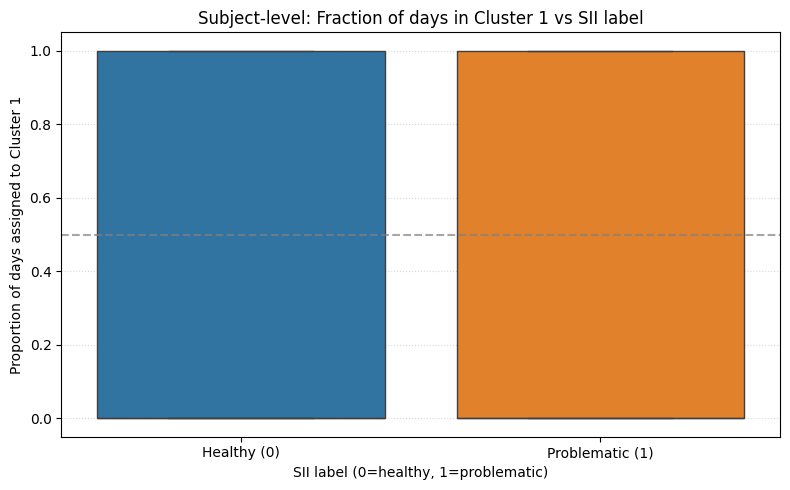

Mann-Whitney U test: p = 0.6668
→ No significant difference.


In [13]:
# CELL 12 — Subject-level aggregation: cluster membership proportion per subject

# Use the original balanced sample labels (seed=42) from Cell 3
# But we need to map day-segment predictions back to original subjects.

# First, get the indices of the sampled days and their corresponding subject IDs
# We have X_days and y_days originally of shape (13420, 48). Each group of 4 consecutive days belongs to one subject.
# Let's reconstruct subject IDs for the sampled days.

subject_id_per_day = np.repeat(np.arange(len(X_train_raw)), 4)  # because each subject contributed 4 days
sampled_subject_ids = subject_id_per_day[sampled_idx]

# Now for each subject in the sample, compute proportion of days in cluster 1 (or 0)
df_subject = pd.DataFrame({
    'subject_id': sampled_subject_ids,
    'cluster': labels_day,
    'true_label': y_sample
})

# Group by subject
subject_agg = df_subject.groupby('subject_id').agg(
    p_cluster1=('cluster', lambda x: (x == 1).mean()),
    true_label=('true_label', 'first')
)

print("Subject-level aggregation (each subject has multiple days):")
print(subject_agg.head())

# Visualize: distribution of cluster1 proportion by true label
plt.figure(figsize=(8, 5))
sns.boxplot(data=subject_agg, x='true_label', y='p_cluster1', palette=['#1f77b4', '#ff7f0e'])
plt.axhline(0.5, linestyle='--', color='gray', alpha=0.7)
plt.xlabel('SII label (0=healthy, 1=problematic)')
plt.ylabel('Proportion of days assigned to Cluster 1')
plt.title('Subject-level: Fraction of days in Cluster 1 vs SII label')
plt.xticks([0, 1], ['Healthy (0)', 'Problematic (1)'])
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Statistical test: Mann-Whitney U test (non-parametric)
from scipy.stats import mannwhitneyu
group0 = subject_agg[subject_agg['true_label'] == 0]['p_cluster1']
group1 = subject_agg[subject_agg['true_label'] == 1]['p_cluster1']
stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")
if p < 0.05:
    print("→ Significant difference in cluster1 proportion between groups.")
else:
    print("→ No significant difference.")